
***Import Libraries***

In [1]:
from symfit import parameters, variables, sin, cos, Fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Reading Data**

*For X direction*

In [44]:
df3= pd.read_csv('freq_x_rot.csv', header = 0)

x_angle = df3['angle']
x_angle = x_angle*np.pi/180.
f_sx = df3['fre_sum']/1E3
f_dx = df3['freq_diff']/1E6
f_1Dx = df3['freq_1D']/1E6 #freq of |1> -> |0>
f_2Dx = df3['freq_2D']/1E6 #freq of |0> -> |-1>


*For Y direction*

In [45]:
df2= pd.read_csv('freq_y_rot.csv', header = 0)


f_sy = df2['fre_sum']/1E3
f_dy= df2['freq_diff']/1E6
f_1Dy = df2['freq_1D']/1E6 #freq of |1> -> |0>
f_2Dy = df2['freq_2D']/1E6 #freq of |0> -> |-1>

*For Z direction*

In [46]:
df1 = pd.read_csv('freq_z_rot.csv', header = 0)

f_sz = df1['fre_sum']/1E3
f_dz= df1['freq_diff']/1E6
f_1Dz = df1['freq_1D']/1E6 #freq of |1> -> |0>
f_2Dz = df1['freq_2D']/1E6 #freq of |0> -> |-1>

***Plotting all frequency data***

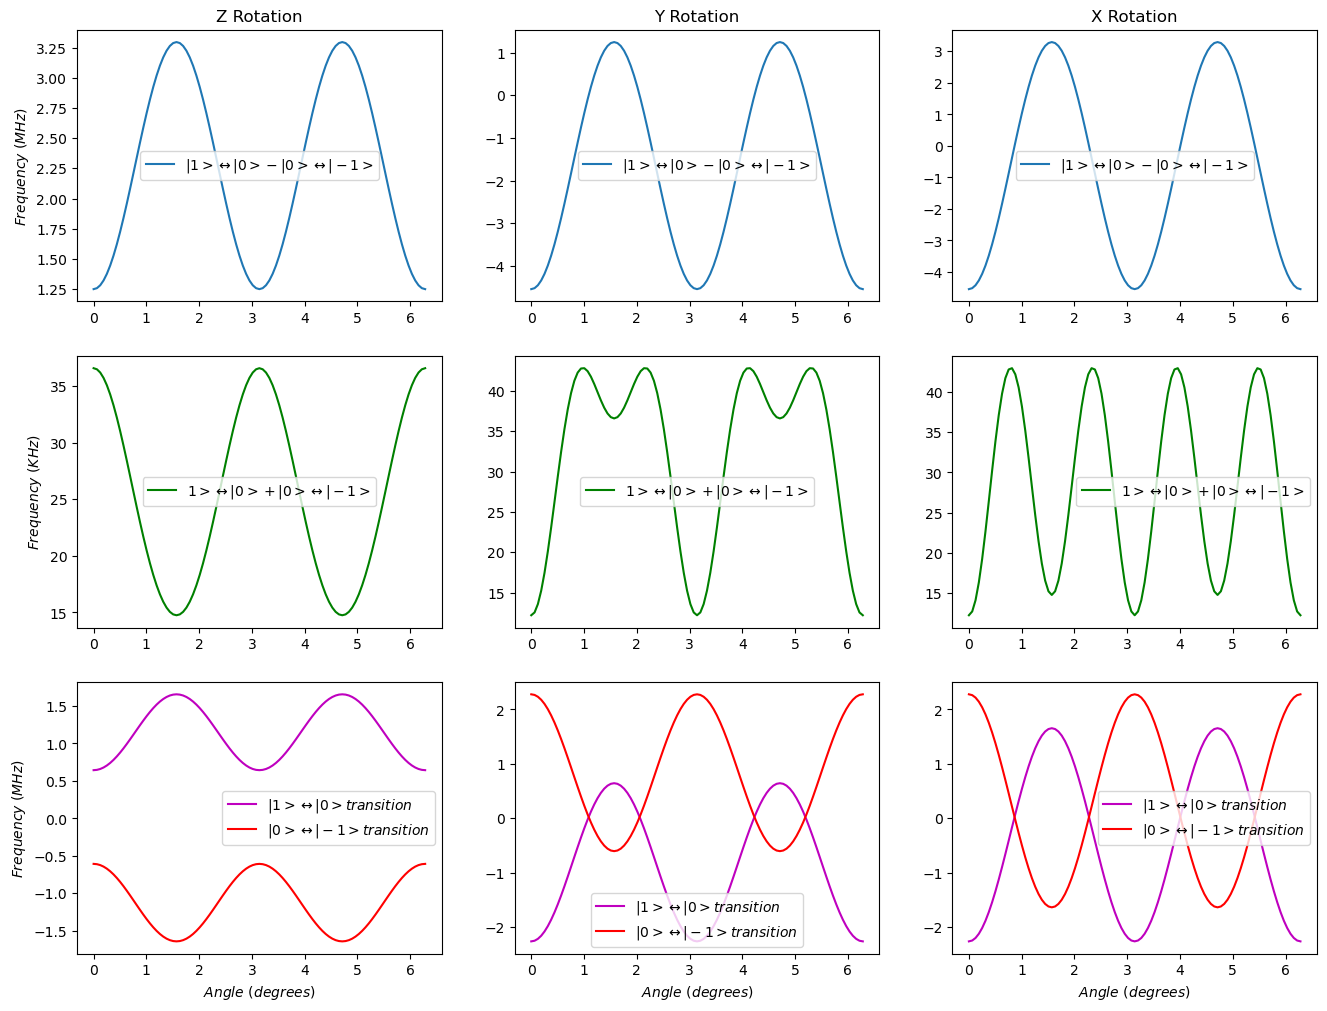

In [48]:
fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(16,12))

# input from z rot file

axes[0,0].plot(x_angle,f_dz, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,0].set_title('Z Rotation')
#axes[0,0].set_ylabel(r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$' + '\n' + 'frequency(Hz)')
axes[0,0].set_ylabel(r'$Frequency\ (MHz)$')
axes[0,0].legend()

axes[1,0].plot(x_angle,f_sz, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
#axes[1,0].set_ylabel(r'$|1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$' + '\n' + 'frequency(KHz)')
axes[1,0].set_ylabel(r'$Frequency\ (KHz)$')
axes[1,0].legend()

axes[2,0].plot(x_angle,f_1Dz, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,0].plot(x_angle,f_2Dz, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,0].set_ylabel(r'$Frequency\ (MHz)$')
axes[2,0].set_xlabel(r'$Angle\ (degrees)$')
axes[2,0].legend()

# input from y rot file

axes[0,1].plot(x_angle,f_dy, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,1].set_title('Y Rotation')
axes[0,1].legend()
axes[1,1].plot(x_angle,f_sy, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
axes[1,1].legend()

axes[2,1].plot(x_angle,f_1Dy, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,1].plot(x_angle,f_2Dy, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,1].set_xlabel(r'$Angle\ (degrees)$')
axes[2,1].legend()

# input from x rot file

axes[0,2].plot(x_angle,f_dx, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,2].set_title('X Rotation')
axes[0,2].legend()

axes[1,2].plot(x_angle,f_sx, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
axes[1,2].legend()

axes[2,2].plot(x_angle,f_1Dx, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,2].plot(x_angle,f_2Dx, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,2].set_xlabel(r'$Angle\ (degrees)$')
axes[2,2].legend()

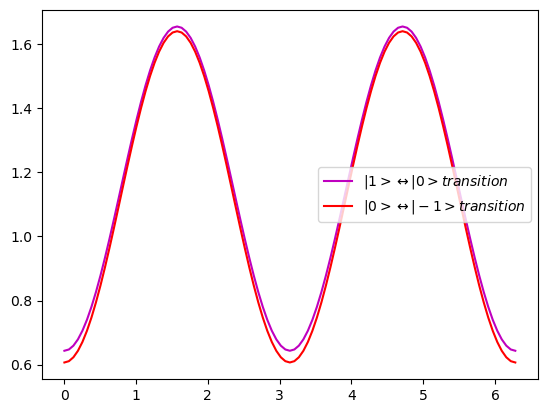

In [6]:
plt.plot(x_angle,f_1Dz, '-m', label = r'$|1>\leftrightarrow|0> transition$')
plt.plot(x_angle,-1*f_2Dz, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
plt.legend()

In [7]:
# #fitting functions
# def Hcsa1(theta,A1, B1, C1):
    
#     freq_csa1 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180)
#     return freq_csa1

# def HQ2 (theta,A1, B1, C1, D1, E1):
#     freq_Q2 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180) + D1*np.cos(4*theta*np.pi/180) + E1*np.sin(4*theta*np.pi/180) 
#     return freq_Q2

**Defining Fourier Series**

In [62]:

def fourier_series(x, f, n=0):
    """
    Returns a symbolic fourier series of order `n`.

    :param n: Order of the fourier series.
    :param x: Independent variable
    :param f: Frequency of the fourier series
    """
    # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, n + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, n + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos(i * f * x ) + bi * sin(i * f * x )
                     for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series

x, y = variables('x, y')
w, = parameters('w')



Note: Fitting can be done using the same function. The terms can be ignored according to the fitting function provided in NMR theory.
Note: Fitting needs input data as float => need to convert frequency into float

***Fitting for X rotation***

In [50]:
fx_s_float = np.array(f_sx, dtype=float) #sum frequency
fx_d_float = np.array(f_dx, dtype = float) #difference frequency
x_float = np.array(x_angle, dtype = float)
# x= np.asarray(x)
# y_sx=np.asarray(y_sx)
# type(x)

Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.824642e+01 2.851711e-14
a1        -1.264300e+00 4.219839e-14
a2        -1.475996e+01 3.921773e-14
b1        -1.013931e-13 3.967097e-14
b2        2.287878e-13 8.517701e-14
w         2.000000e+00 8.135025e-16
Status message         Optimization terminated successfully.
Number of iterations   27
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa26a520b20>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa26a523790>

Goodness of fit qualifiers:
chi_squared            7.42589164420006e-24
objective_value        3.71294582210003e-24
r_squared              1.0


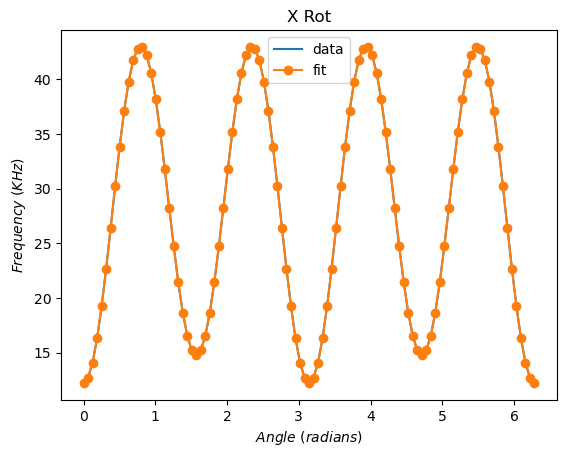

In [51]:

#providing data
xdata = x_float
ydata = fx_s_float

#Generate Fit function
model_dict = {y: fourier_series(x, f=w, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_x_s = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_x_s)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_x_s.params).y, marker="o", label = "fit")
plt.title('X Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

Fitting Function: {y: a0 + a1*cos(2*x) + b1*sin(2*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        -6.253021e-01 2.642079e-05
a1        -3.920055e+00 3.718103e-05
b1        5.551115e-16 3.754736e-05
Status message         Optimization terminated successfully.
Number of iterations   6
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa263ab3be0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa263ab2ec0>

Goodness of fit qualifiers:
chi_squared            6.908040339853195e-06
objective_value        3.4540201699265974e-06
r_squared              0.9999999911837356


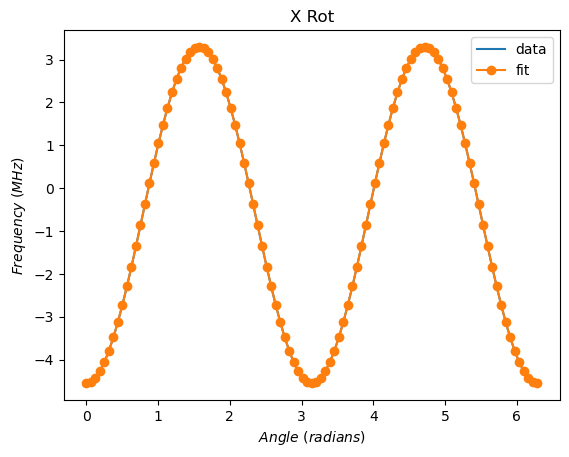

In [52]:
#Providing data
xdata = x_float
ydata = fx_d_float

#Generating Fit function
model_dict = {y: fourier_series(x, f=2, n=1)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_x_d = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_x_d)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_x_d.params).y, marker="o", label = "fit")
plt.title('X Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (MHz)$')
plt.legend()
plt.show()

In [12]:
a1 = fit_result_x_d.params['a0']
a1

-0.6253020686669069

***Fitting for Y rotation***

In [53]:
fy_s_float = np.array(f_sy, dtype=float) #sum frequency
fy_d_float = np.array(f_dy, dtype=float) #difference frequency


Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        3.245884e+01 2.202122e-14
a1        -1.217312e+01 3.079824e-14
a2        -8.063570e+00 2.862967e-14
b1        3.623988e-14 4.395338e-14
b2        -1.123842e-14 5.256844e-14
w         2.000000e+00 8.677151e-16
Status message         Optimization terminated successfully.
Number of iterations   34
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa263921db0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa2639220e0>

Goodness of fit qualifiers:
chi_squared            3.9459264241261934e-24
objective_value        1.9729632120630967e-24
r_squared              1.0


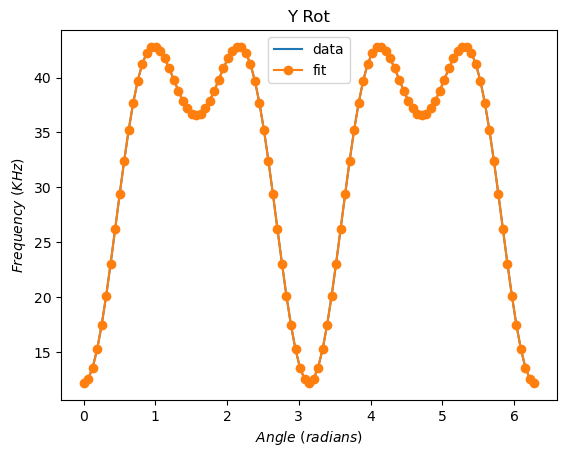

In [54]:
#Providing data
xdata = x_float
ydata = fy_s_float

#Generating Fit Fucntion
model_dict = {y: fourier_series(x, f=w, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_y_s = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_y_s)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_y_s.params).y, marker="o", label = "fit")
plt.title('Y Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

Fitting Function: {y: a0 + a1*cos(2*x) + b1*sin(2*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        -1.647766e+00 1.478212e-05
a1        -2.897434e+00 2.080235e-05
b1        2.897438e-04 2.100730e-05
Status message         Optimization terminated successfully.
Number of iterations   6
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa263fa6920>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa263fa5720>

Goodness of fit qualifiers:
chi_squared            2.162403394950435e-06
objective_value        1.0812016974752175e-06
r_squared              0.9999999949484588


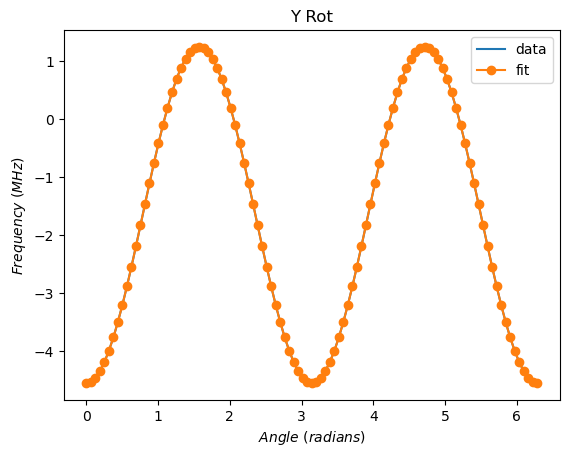

In [15]:
#Providing data
xdata = x_float
ydata = fy_d_float

#genearting fit function
model_dict = {y: fourier_series(x, f=2, n=1)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_y_d = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_y_d)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_y_d.params).y, marker="o", label = "fit")
plt.title('Y Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (MHz)$')
plt.legend()
plt.show()

***Fitting For Z rotation***

In [55]:
fz_s_float = np.array(f_sz, dtype=float) #sum frequency
fz_d_float = np.array(f_dz, dtype = float) #difference frequency

Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.532475e+01 3.765939e-14
a1        1.090882e+01 4.896842e-14
a2        3.348195e-01 4.929854e-14
b1        -1.573856e-13 1.079976e-13
b2        3.650653e-13 4.903092e-14
w         2.000000e+00 2.813098e-15
Status message         Optimization terminated successfully.
Number of iterations   31
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa2639b65c0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa2639b7490>

Goodness of fit qualifiers:
chi_squared            1.1252791579502887e-23
objective_value        5.6263957897514434e-24
r_squared              1.0


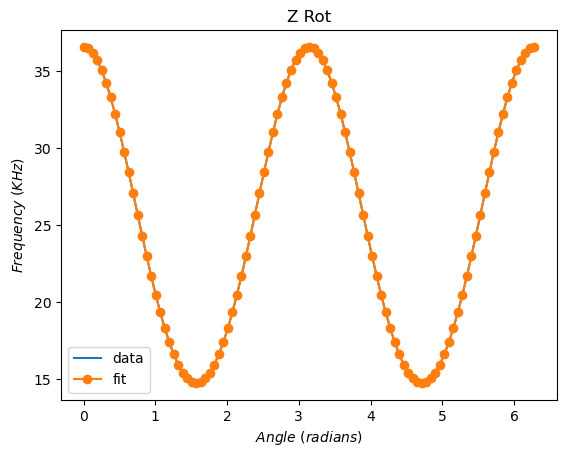

In [56]:
#Providing data

xdata = x_float
ydata = fz_s_float

#generating fit function
model_dict = {y: fourier_series(x, f=w, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_z_s = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_z_s)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_z_s.params).y, marker="o", label = "fit")
plt.title('Z Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

Fitting Function: {y: a0 + a1*cos(2*x) + b1*sin(2*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.272488e+00 1.422136e-06
a1        -1.022625e+00 2.001321e-06
b1        6.383782e-16 2.021039e-06
Status message         Optimization terminated successfully.
Number of iterations   6
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa263c4c5b0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa263c4eef0>

Goodness of fit qualifiers:
chi_squared            2.001453295455088e-08
objective_value        1.000726647727544e-08
r_squared              0.9999999996246581


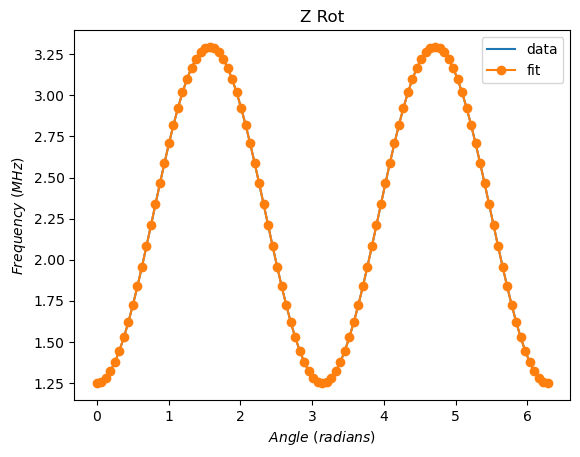

In [18]:
#Providing data

xdata = x_float
ydata = fz_d_float

#Generating Fit function
model_dict = {y: fourier_series(x, f=2, n=1)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_z_d = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_z_d)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_z_d.params).y, marker="o", label = "fit")
plt.title('Z Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (MHz)$')
plt.legend()
plt.show()

**Finding quadrupolar components from $H_Q^1$**

Missing factor of $\frac{3eQ}{4h}$

In [57]:
A1 = fit_result_x_d.params['a0']
B1 = fit_result_x_d.params['a1']
C1 = fit_result_x_d.params['b1']

A2 = fit_result_y_d.params['a0']
B2 = fit_result_y_d.params['a1']
C2 = fit_result_y_d.params['b1']

A3 = fit_result_z_d.params['a0']
B3 = fit_result_z_d.params['a1']
C3 = fit_result_z_d.params['b1']

A = np.array([[1, 1], [1, -1]])
B = np.array([A1, B1])
X1 = np.linalg.inv(A).dot(B)
gzz_q = X1[0]
gyy_q= X1[1]
gyz_q = -2*C1

A = np.array([[1, 1], [1, -1]])
B = np.array([A2, B2])
X2 = np.linalg.inv(A).dot(B)
gzz_q = X2[0]
gxx_q = X2[1]
gxz_q = 2*C2

A = np.array([[1, 1], [1, -1]])
B = np.array([A3, B3])
X3 = np.linalg.inv(A).dot(B)
gxx_q = X3[0]
gyy_q = X3[1]
gxy_q = -2*C3

y = [gzz_q, gyy_q, gxx_q, gyz_q, gxz_q, gxy_q]
print(y)

[-2.2725999862079, 1.6475566079921726, 0.6249318346078587, -1.1102230246251565e-15, 0.0005794875000006972, -1.27675647831893e-15]


**$H_Q^2$ Coefficients**
Missing $\frac{X_Q^2}{\omega_0}$

In [58]:
Ax = (23/32*(gzz_q**2 + gyy_q**2) + 26/32*gzz_q*gyy_q + 5/8*gyz_q**2 + gxz_q**2 + gxy_q**2)
Bx = -3/8*(gzz_q**2 - gyy_q**2)
Cx = 3/4*(gzz_q + gyy_q)*gyz_q
Dx = 3/8*(gyz_q**2 - 1/4*(gzz_q - gyy_q)**2)
Ex = 3/8*((gzz_q - gyy_q)*gyz_q)

Ay = (23/32*(gzz_q**2 + gxx_q**2) + 26/32*gzz_q*gxx_q + 5/8*gxz_q**2 + gyz_q**2 + gxy_q**2)
By = -3/8*(gzz_q**2 - gxx_q**2)
Cy = -3/4*((gzz_q + gxx_q)*gxz_q)
Dy = 3/8*(gxz_q**2 - 1/4*(gzz_q - gxx_q)**2)
Ey = -3/8*((gzz_q - gxx_q)*gxz_q)

Az = (23/32*(gxx_q**2 + gyy_q**2) + 26/32*gxx_q*gyy_q + 5/8*gxy_q**2 + gyz_q**2 + gxz_q**2)
Bz = -3/8*(gxx_q**2 - gyy_q**2)
Cz = 3/4*(gxx_q + gyy_q)*gxy_q
Dz = 3/8*(gxy_q**2 - 1/4*(gxx_q - gyy_q)**2)
Ez = 3/8*((gxx_q - gyy_q)*gxy_q)


**Finding HQ2**

In [59]:
HQ2_x = Ax + Bx*np.cos(2*x_angle) + Cx*np.sin(2*x_angle) + Dx*np.cos(4*x_angle) + Ex*np.sin(4*x_angle)
HQ2_y = Ay + By*np.cos(2*x_angle) + Cy*np.sin(2*x_angle) + Dy*np.cos(4*x_angle) + Ey*np.sin(4*x_angle)
HQ2_z = Az + Bz*np.cos(2*x_angle) + Cz*np.sin(2*x_angle) + Dz*np.cos(4*x_angle) + Ez*np.sin(4*x_angle)

**Fitting of sum frequency with No $H_Q^2$**

Fitting Function: {y: a0 + a1*cos(2*x) + a2*cos(4*x) + b1*sin(2*x) + b2*sin(4*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.562547e+01 2.129600e-14
a1        -3.454497e-01 2.997194e-14
a2        -1.331925e+01 2.997194e-14
b1        -1.725954e-14 3.026153e-14
b2        4.651345e-15 3.026153e-14
Status message         Optimization terminated successfully.
Number of iterations   8
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa263868700>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa2638694b0>

Goodness of fit qualifiers:
chi_squared            4.3956497153054505e-24
objective_value        2.1978248576527252e-24
r_squared              1.0
Fit result:
 
Parameter Value        Standard Deviation
a0        2.824642e+01 2.851711e-14
a1        -1.264300e+00 4.219839e-14
a2        -1.475996e+01 3.921773e-14
b1        -1.013931e-13 3.967097e-14
b2        2.287878e-13 8.517701e-14
w         2.000000e+00 8.135025e-16
Status

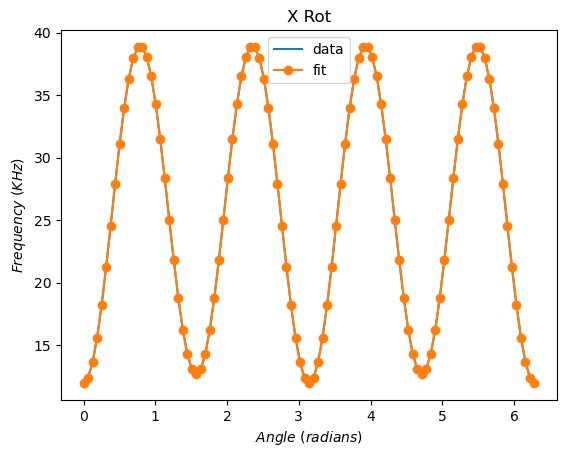

In [63]:
#providing data
xdata = x_float
ydata = np.array((f_sx - HQ2_x), dtype = float) #subtracting HQ2 contribution from sum frequency

#Generate Fit function
model_dict = {y: fourier_series(x, f=2, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_x_csa = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_x_csa)
print('Fit result:''\n',fit_result_x_s)
# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_x_csa.params).y, marker="o", label = "fit")
plt.title('X Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

Fitting Function: {y: a0 + a1*cos(2*x) + a2*cos(4*x) + b1*sin(2*x) + b2*sin(4*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.961994e+01 3.514019e-13
a1        -1.038280e+01 4.945624e-13
a2        -7.276474e+00 4.945624e-13
b1        -7.161023e-04 4.993409e-13
b2        -6.296563e-04 4.993409e-13
Status message         Optimization terminated successfully.
Number of iterations   6
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa26375e3b0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa26375f160>

Goodness of fit qualifiers:
chi_squared            1.1968382105659449e-21
objective_value        5.984191052829724e-22
r_squared              1.0
Fit result:
 
Parameter Value        Standard Deviation
a0        3.245884e+01 2.202122e-14
a1        -1.217312e+01 3.079824e-14
a2        -8.063570e+00 2.862967e-14
b1        3.623988e-14 4.395338e-14
b2        -1.123842e-14 5.256844e-14
w         2.000000e+00 8.677151e-16
Status

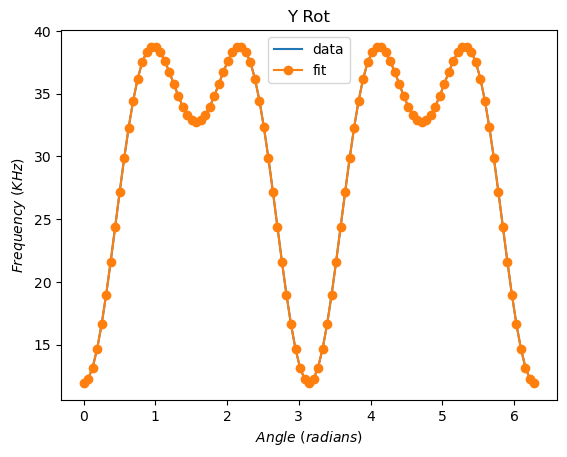

In [64]:
#providing data
xdata = x_float
ydata = np.array((f_sy - HQ2_y), dtype = float)
type(ydata)
#Generate Fit function
model_dict = {y: fourier_series(x, f=2, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_y_csa = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_y_csa)
print('Fit result:''\n',fit_result_y_s)
# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_y_csa.params).y, marker="o", label = "fit")
plt.title('Y Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

Fitting Function: {y: a0 + a1*cos(w*x) + b1*sin(w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.228882e+01 3.323111e-02
a1        1.005809e+01 4.327283e-02
b1        -1.790258e-01 9.406536e-02
w         1.994335e+00 2.639164e-03
Status message         Desired error not necessarily achieved due to precision loss.
Number of iterations   33
Objective              <symfit.core.objectives.LeastSquares object at 0x7fa2637ea830>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7fa2637ea680>

Goodness of fit qualifiers:
chi_squared            9.11917472103699
objective_value        4.559587360518495
r_squared              0.9982311178497035
Fit result:
 
Parameter Value        Standard Deviation
a0        2.532475e+01 3.765939e-14
a1        1.090882e+01 4.896842e-14
a2        3.348195e-01 4.929854e-14
b1        -1.573856e-13 1.079976e-13
b2        3.650653e-13 4.903092e-14
w         2.000000e+00 2.813098e-15
Status message         Optimization terminate

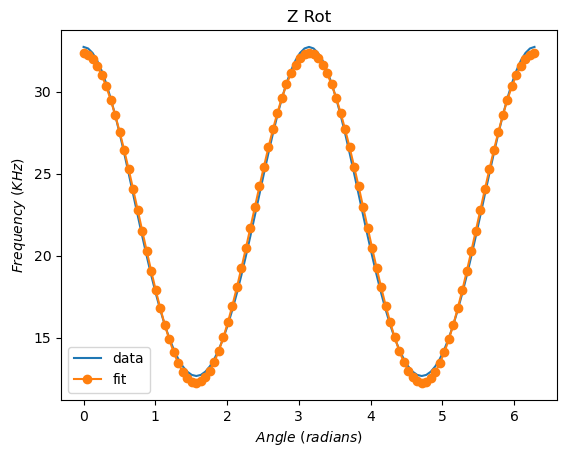

In [65]:
#providing data
xdata = x_float
ydata = np.array((f_sz - HQ2_z), dtype = float)
type(ydata)
#Generate Fit function
model_dict = {y: fourier_series(x, f=w, n=1)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result_z_csa = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result_z_csa)
print('Fit result:''\n',fit_result_z_s)
# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result_z_csa.params).y, marker="o", label = "fit")
plt.title('Z Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

**Finding $H_{CSA}^1$**

In [66]:
A1 = fit_result_x_csa.params['a0']
B1 = fit_result_x_csa.params['a1']
C1 = fit_result_x_csa.params['b1']

A2 = fit_result_y_csa.params['a0']
B2 = fit_result_y_csa.params['a1']
C2 = fit_result_y_csa.params['b1']

A3 = fit_result_z_csa.params['a0']
B3 = fit_result_z_csa.params['a1']
C3 = fit_result_z_csa.params['b1']

A = np.array([[1, 1], [1, -1]])
B = np.array([A1, B1])
X1 = np.linalg.inv(A).dot(B)
gzz_csa = X1[0]
gyy_csa = X1[1]
gyz_csa = -2*C1

A = np.array([[1, 1], [1, -1]])
B = np.array([A2, B2])
X2 = np.linalg.inv(A).dot(B)
gzz_csa = X2[0]
gxx_csa = X2[1]
gxz_csa = 2*C2

A = np.array([[1, 1], [1, -1]])
B = np.array([A3, B3])
X3 = np.linalg.inv(A).dot(B)
gxx_csa = X3[0]
gyy_csa = X3[1]
gxy_csa = -2*C3

# y = [gzz_csa, gyy_csa, gyz_csa, gxx_csa, gxz_csa, gxy_csa]
# #print(A1, B1, C1, A2, B2, C2, A3, B3, C3)
# print('CSA components are:',y)


In [67]:
from tabulate import tabulate
print(tabulate([['gzz_CSA',gzz_csa], ['gyy_CSA',gyy_csa], ['gxx_CSA',gyy_csa], ['gxy_CSA',gxy_csa], ['gxz_CSA',gxz_csa], ['gyz_CSA',gyz_csa],['gzz_Q',gzz_q], ['gyy_Q',gyy_q], ['gxx_Q',gyy_q], ['gxy_Q',gxy_q], ['gxz_Q',gxz_q], ['gyz_Q',gyz_q]]))
#print(tabulate([['Ax_CSA1',A1], ['Bx_CSA1',B1], ['Cx_CSA1',C1], ['Ay_CSA1',A2], ['By_CSA1',B2], ['Cy_CSA1',C2],['Az_CSA1',A3], ['Bz_CSA1',B3], ['Cz_CSA1',C3]]))

-------  ------------
gzz_CSA   9.61857
gyy_CSA   6.11537
gxx_CSA   6.11537
gxy_CSA   0.358052
gxz_CSA  -0.0014322
gyz_CSA   3.45191e-14
gzz_Q    -2.2726
gyy_Q     1.64756
gxx_Q     1.64756
gxy_Q    -1.27676e-15
gxz_Q     0.000579488
gyz_Q    -1.11022e-15
-------  ------------


**Finding $H_{Q, CSA}$**

Missing $\frac{X_QB_0}{\omega_0}$

In [27]:
A_x = 3*(gyz_q*gyz_csa + gxz_q*gxz_csa - 1/4*(gzz_q - gyy_q)*(gyy_csa - gzz_csa))
B_x = 3*(gxz_q*gxz_csa + gxy_q*gxy_csa)
C_x = 3*(gxz_q*gxy_csa - gxy_q*gxz_csa)
D_x = 3*(gyz_q*gyz_csa - 1/4*(gzz_q-gyy_q)*(gzz_csa - gyy_csa))
E_x = -3/2*(gyz_q*(gzz_csa - gyy_csa) + (gzz_q - gyy_q)*gyz_csa)

A_y = 3*(gyz_q*gyz_csa + gxz_q*gxz_csa - 1/4*(gzz_q - gxx_q)*(gxx_csa - gzz_csa))
B_y = 3*(gyz_q*gyz_csa - gxy_q*gxy_csa)
C_y = 3*(gxy_q*gyz_csa + gyz_q*gxy_csa)
D_y = 3*(gxz_q*gxz_csa - 1/4*(gzz_q-gxx_q)*(gzz_csa - gxx_csa))
E_y = -3/2*(gxz_q*(gzz_csa - gxx_csa) + (gzz_q - gxx_q)*gxz_csa)

A_z = 3*(gyz_q*gyz_csa + gxz_q*gxz_csa - 1/4*(gxx_q - gyy_q)*(gyy_csa - gxx_csa))
B_z = 3*(gxz_q*gxz_csa - gyz_q*gyz_csa)
C_z = -3*(gyz_q*gxz_csa + gxz_q*gyz_csa)
D_z = 3*(gxy_q*gxy_csa - 1/4*(gxx_q-gyy_q)*(gxx_csa - gyy_csa))
E_z = 3/2*(gxy_q*(gxx_csa - gyy_csa) + (gxx_q - gyy_q)*gxy_csa)

In [28]:
fz_float = np.array(f_sz, dtype=float)
type(fz_float)
# fzd_float = np.array(f_dz, dtype = float)

# data = np.vstack([fz_float, fzd_float])

numpy.ndarray

Plotting Acs and No acs data

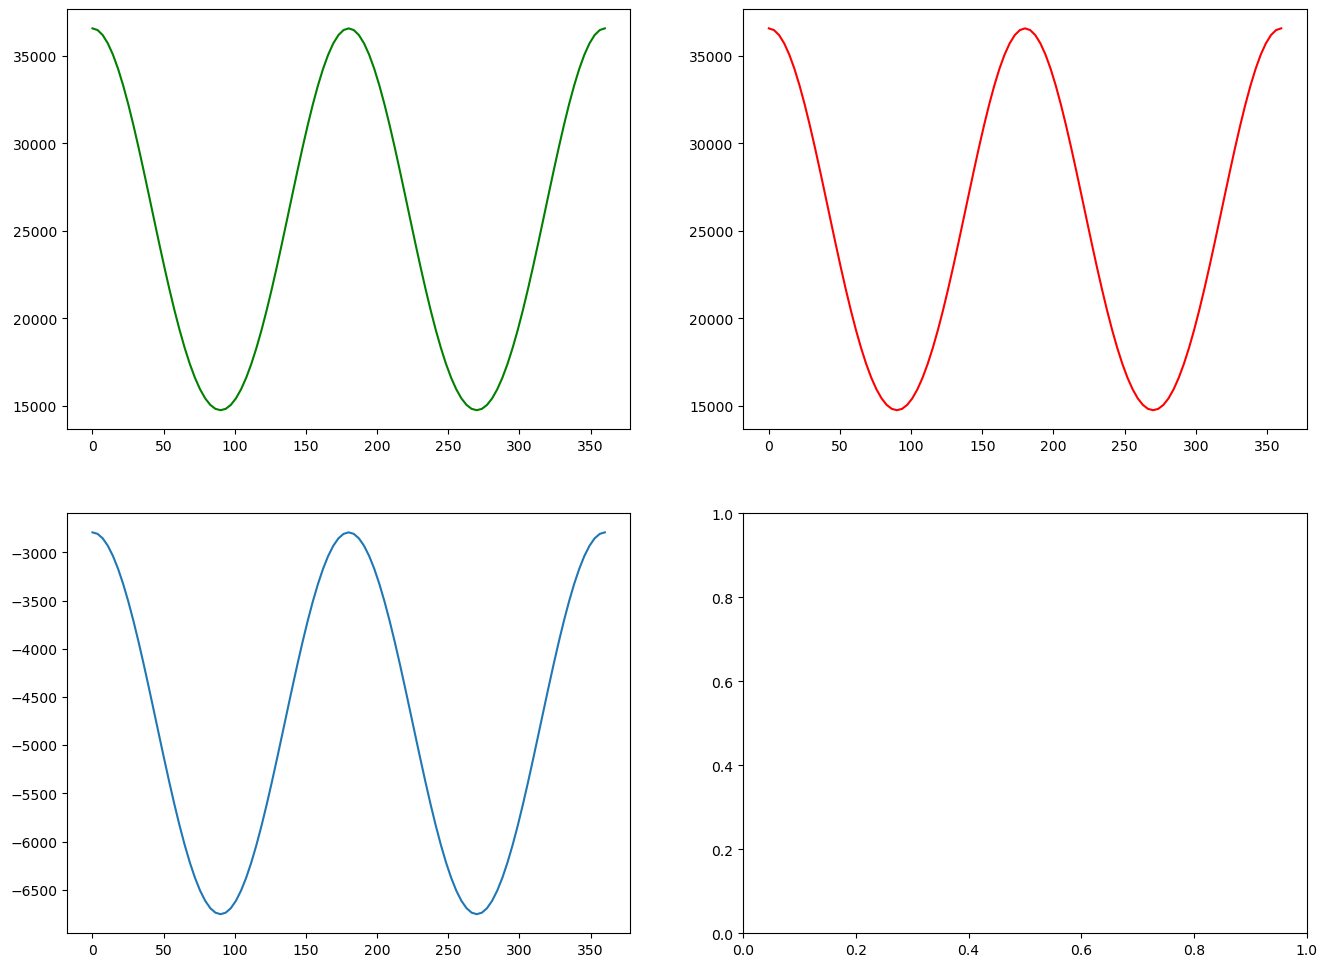

In [29]:
fig, axes = plt.subplots(nrows=2, ncols=2,figsize=(16,12))
dfa= pd.read_csv('freq_z_rot.csv', header = 0)
dfb = pd.read_csv('noacsfreq_z_rot.csv', header = 0)
dfc = pd.read_csv('/home/shiva/Scripts/Python/nocqfreq_z_rot.csv', header = 0)

x_angle = dfa['angle']
f_s_acs = dfa['fre_sum']
f_s_noacs = dfb['fre_sum']
f_snocq = dfc['fre_sum']
axes[0,0].plot(x_angle,f_s_acs, '-g')
axes[0,1].plot(x_angle, f_s_noacs, '-r')
axes[1,0].plot(x_angle, f_snocq)

In [30]:
for i in range(0, 1):
    xdata = x_float
    ydata = data

    # Define a Fit object for this model and data
    fit[i] = Fit(model_dict, x=xdata, y=ydata[i])
    fit_result = fit.execute()
    print('Fitting Function:',model_dict)
    print('Fit result:''\n',fit_result)

    # Plot the result
    plt.plot(xdata, ydata[i], label = "data")
    plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
    plt.title('Y Rot')
    plt.xlabel(r'$Angle\ (radians)$')
    plt.ylabel(r'$Frequency\ (KHz)$')
    plt.legend()
    plt.show()
    


NameError: name 'data' is not defined